# Cylinder wake reduced model: POD + shift, SINDy, and Brunton Eq. 8 validation

**Same spirit as `Run_Lorenz.ipynb`:** generate reference dynamics, fit SINDy with **exact derivatives** (Brunton-style validation), then check **structure** with `compare_to_truth`.

We also exercise the **high-dimensional → three coordinates** path from `cylinder_flow/snapshot_pod_shift.py` by embedding the 3D trajectory in a random subspace and recovering POD + shift modes.

**Environment:** install repo `requirements.txt` (needs `numpy`, `scipy`, `scikit-learn`, `sympy`, `matplotlib`). Example: `pip install -r requirements.txt`.


In [1]:
# Imports
import sys
from pathlib import Path

root = Path(".").resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import os
import numpy as np
import matplotlib.pyplot as plt

from cylinder_flow.mean_field_simulator import (
    simulate_cylinder_mean_field,
    DEFAULT_ILLUSTRATIVE_PARAMS,
)
from cylinder_flow.snapshot_pod_shift import pod_shift_coefficients
from cylinder_flow.mean_field_sindy_model import (
    build_cylinder_mean_field_model,
    cylinder_mean_field_polynomial_budget,
    cylinder_sindy_config_bic_standard,
)
from sindy.pipeline import run_sindy_pipeline_general
from idtools.compare_to_truth import compare_to_truth
from lorenz.integrated import integrated_3d_comparison

%matplotlib inline


## 1. Reference trajectory (ideal Brunton / Noack mean field, Eq. 8)

States $(x,y,z)$ are the two leading POD coefficients and the shift mode in the PNAS cylinder discussion. We integrate with `simulate_cylinder_mean_field` using `DEFAULT_ILLUSTRATIVE_PARAMS` (illustrative; replace with fitted values for real DNS).

**Time base:** `t` must match the physical (or simulation) clock used to generate your snapshots. Standard Brunton-style cylinder snapshot data (e.g. `cy10.snapshot`) is often produced over **~200 time units**; if you instead integrate or interpolate with the wrong total duration, `dt` is wrong and SINDy will rescale every coefficient that multiplies time (e.g. $\omega$, $\mu$, $\lambda$). Below we use `T_END = 200` so the demo matches that convention; for real data, set `t` from file metadata or known `dt`.


In [2]:
params = DEFAULT_ILLUSTRATIVE_PARAMS
# Match typical Brunton cylinder snapshot duration (~200 time units); keep integration span == t span.
T_END = 200.0
N_SAMPLES = 3000
t = np.linspace(0.0, T_END, N_SAMPLES)
z0 = np.array([0.15, 0.02, 0.0], dtype=float)

sol = simulate_cylinder_mean_field(
    (float(t[0]), float(t[-1])),
    z0,
    t_eval=t,
    params=params,
)
assert sol.success, sol.message
Z_phys = sol.y.T  # (n_times, 3) — "data" in (x, y, z)

rng = np.random.default_rng(0)
noise_std = 0.02 * np.std(Z_phys, axis=0)
Z_noisy = Z_phys + rng.standard_normal(Z_phys.shape) * noise_std

print(f"t: {t.size} samples, dt ≈ {np.median(np.diff(t)):.5f}")
print(f"Z_phys shape {Z_phys.shape}, noise_std per state {noise_std}")


t: 3000 samples, dt ≈ 0.06669
Z_phys shape (3000, 3), noise_std per state [0.00438383 0.00439574 0.00025788]


## 2. Synthetic POD + shift pipeline (embedded snapshots)

Mimics `cy10.snapshot`-style data: build a high-dimensional snapshot matrix $X \in \mathbb{R}^{n\times T}$ whose columns lie in a fixed 3D subspace, then run `pod_shift_coefficients` with a zero base flow and compare recovered coordinates to the embedded trajectory.

**POD vs projection:** `phi1`,`phi2` from `svd(X - mean_t(X))` (fluctuations only, so the mean shift does not dominate the shedding subspace). Amplitudes: `phi_k @ (X - u_base)` and shift coord from `delta_u @ (X - u_base)` with `delta_u` from `mean_t(X)-u_base` orthogonal to `phi1`,`phi2`.


In [3]:
n_grid = 80
Q, _ = np.linalg.qr(rng.standard_normal((n_grid, 3)))
X_snapshots = Q @ Z_phys.T  # (n_grid, n_times)
u_base = np.zeros(n_grid)

pod = pod_shift_coefficients(X_snapshots, u_base, time_axis=1)
Z_pod = pod.Z_sindy

corrs = []
for i in range(3):
    corrs.append([abs(np.corrcoef(Z_phys[:, i], Z_pod[:, j])[0, 1]) for j in range(3)])
corrs = np.array(corrs)
print("|Pearson corr| between Z_phys columns and Z_pod columns (rows=data x,y,z):")
print(np.round(corrs, 4))
print("best match per row:", corrs.max(axis=1))
print("temporal mean of recovered a3 (shift coord):", float(np.mean(pod.a3)))
print("a3_scale_applied:", pod.a3_scale_applied)


|Pearson corr| between Z_phys columns and Z_pod columns (rows=data x,y,z):
[[1.970e-01 9.804e-01 0.000e+00]
 [9.806e-01 1.959e-01 1.000e-04]
 [2.080e-02 4.400e-03 9.998e-01]]
best match per row: [0.9803973  0.98061997 0.99977405]
temporal mean of recovered a3 (shift coord): 0.09629869639116649
a3_scale_applied: 1.0


## 3. Truth model, polynomial library, exact $\dot{\mathbf{x}}$

Symbolic RHS matches the same parameters as the simulator so `compare_to_truth` is meaningful.


In [4]:
model = build_cylinder_mean_field_model(params)
budget = cylinder_mean_field_polynomial_budget()

Z_dot_phys = np.column_stack([
    model.rhs_lambdified[i](*Z_phys.T) for i in range(len(model.rhs_lambdified))
])


## 4. SINDy pipeline (Pareto + BIC, unscaled state)

`cylinder_sindy_config_bic_standard()` uses **identity** state scaling (raw ``x,y,z``), **`normalize_library_columns=True`**, and **`pareto_dial=1`** (dense Pareto end). Normalized Θ plus plain BIC often zeros the ``dz/dt`` row; the dial restores a model rich enough for Eq.~8.


=== Excitation Report ===
OK: True (data_ok=True, theta_ok=True)

Data excitation:
- State std ratio (max/median)=1.0 → maxabs OK (default)

Theta excitation:
- Theta shape: 3000 x 9, cond=3.914e+03, eff_rank=9 (1.00 frac)
- Library col norm ratio (max/median)=16.8 → raw OK (paper-like default)
- Pseudo-constant features (low CV): 1 (showing up to 10)
  1
- Top abs correlations (Theta columns):
  0.9961  y vs y*z
  0.9961  x vs x*z

Warnings:
- Theta excitation: highly collinear features remain (top): [(0.9961, 'y', 'y*z'), (0.9961, 'x', 'x*z')]
- Theta excitation: 1 pseudo-constant features (low CV).


/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


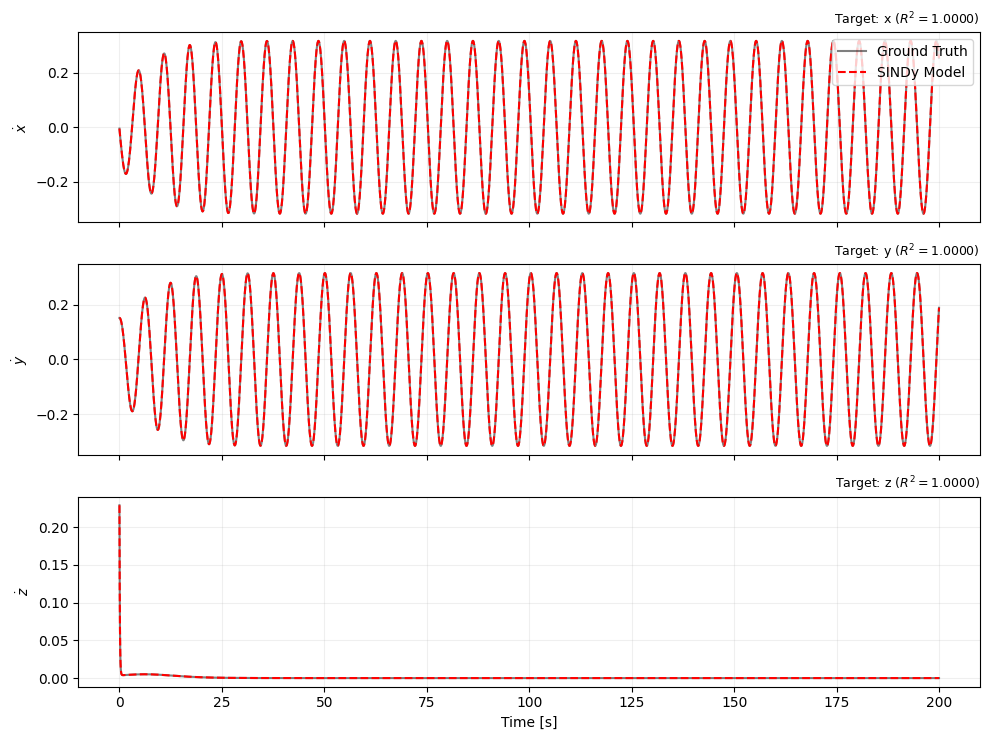

/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


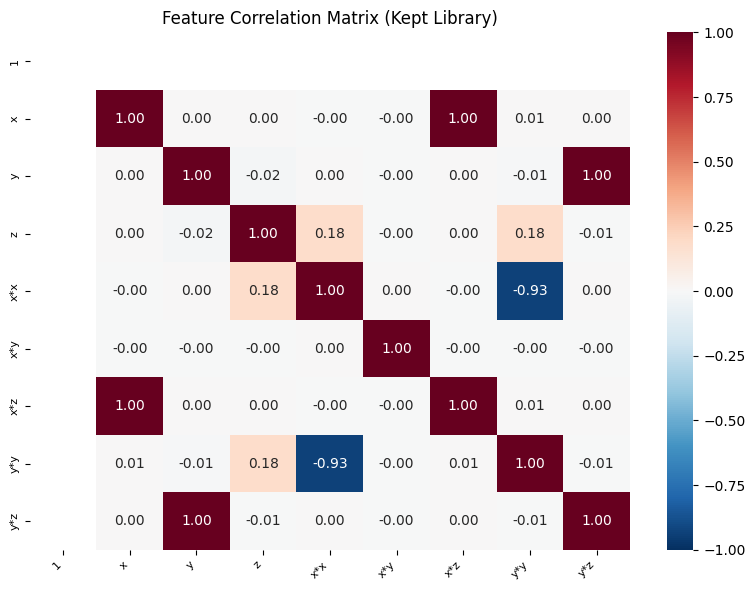

R2(mean): 1.0000, RMSE: 1.746e-16
R² per target (x, y, z): 1.0000, 1.0000, 1.0000
Discovered equations:
  dx/dt = -x*z + 0.1*x - y
  dy/dt = x - y*z + 0.1*y
  dz/dt = 10.0*x**2 + 10.0*y**2 - 10.0*z

  TRUE vs DISCOVERED (structure recovery vs curve fitting)

True equations (from model):
  dx/dt = -1.0*x*z + 0.1*x - 1.0*y
  dy/dt = 1.0*x - 1.0*y*z + 0.1*y
  dz/dt = 10.0*x**2 + 10.0*y**2 - 10.0*z

Discovered equations:
  dx/dt = -x*z + 0.1*x - y
  dy/dt = x - y*z + 0.1*y
  dz/dt = 10.0*x**2 + 10.0*y**2 - 10.0*z

Coefficient comparison (physical units, same library terms):
  Correlation(true, discovered) = 1.0000
  Mean relative error (on true nonzero terms) = 0.6201
  Max relative error (on true nonzero terms)  = 1.0000

  -> Moderate agreement: some structure recovered; check terms with large rel error.



/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'xi_true': array([[-2.00250595e-09,  2.51782999e-09,  8.16379915e-07],
        [ 9.99999015e-02,  9.99999996e-01,  2.85473268e-06],
        [-9.99999985e-01,  9.99999055e-02, -3.14263270e-07],
        [-9.69271006e-07, -5.50952864e-09, -9.99950246e+00],
        [ 9.89317310e-07, -2.01408744e-08,  9.99949430e+00],
        [-9.99998996e-01,  4.40822125e-08, -2.88804860e-05],
        [ 9.89456778e-07, -1.99193641e-08,  9.99949423e+00],
        [-1.47038246e-07, -9.99999036e-01,  3.16876134e-06]]),
 'xi_disc': array([[ 0.00000000e+00,  0.00000000e+00, -7.50477034e-16],
        [ 1.00000000e-01,  1.00000000e+00, -1.06604611e-15],
        [-1.00000000e+00,  1.00000000e-01,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -1.00000000e+01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+01],
        [-1.00000000e+00, -1.20317381e-14,  1.64703991e-14],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+01],
        [-4.40039675e-15, -1.00000000e+00,  0.00000000e+00]])

In [5]:
output_dir = "outputs/cylinder_wake/bic_standard/"
os.makedirs(output_dir, exist_ok=True)

cfg = cylinder_sindy_config_bic_standard()
res = run_sindy_pipeline_general(
    t=t,
    Z_phys=Z_phys,
    model=model,
    budget=budget,
    config=cfg,
    Z_dot_phys=Z_dot_phys,
    run_diagnostics=True,
    output_dir=output_dir,
)

val = res["validation"]
print(f"R2(mean): {val['r2_mean']:.4f}, RMSE: {val['rmse']:.4g}")
r2b = val.get("r2_by_state")
if r2b is not None:
    r2b = np.asarray(r2b).ravel()
    print(f"R² per target (x, y, z): {r2b[0]:.4f}, {r2b[1]:.4f}, {r2b[2]:.4f}")
print("Discovered equations:")
for name, expr in res["fit"]["equations"].items():
    print(f"  d{name}/dt = {expr}")

compare_to_truth(res, verbose=True)


## 5. 3D trajectory: reference data vs SINDy forward integration

Forward-integrate the discovered ODE from the same initial condition as the training data (subsample time for speed).


RMSE(state) on subsampled grid ≈ 2.083e-08


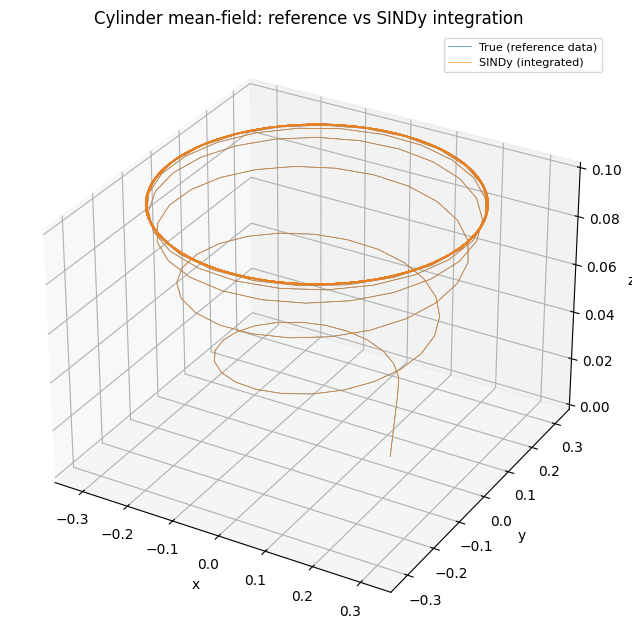

In [6]:
T_STRIDE = 4
out_3d = integrated_3d_comparison(
    res,
    t,
    Z_phys,
    out_path=output_dir + "cylinder_3d_true_vs_sindy.png",
    title="Cylinder mean-field: reference vs SINDy integration",
    t_subsample_step=T_STRIDE,
    include_true_reintegrated=False,  # Lorenz-only helper; Brunton re-integration is plotted in §6
)
print(f"RMSE(state) on subsampled grid ≈ {out_3d['rmse_state']:.4g}")
plt.show()


## 6. Time series: noisy measurements vs ideal Brunton model vs SINDy

- **Noisy measurements** — reference trajectory + Gaussian noise (visual “sensor” realism only; SINDy above used clean states + exact derivatives).
- **Brunton Eq. 8** — re-integrate the *same* mean-field ODE and parameters from `z0` (noise-free reference model).
- **SINDy** — forward model from the discovered sparse ODE (same subsampled times as §5).


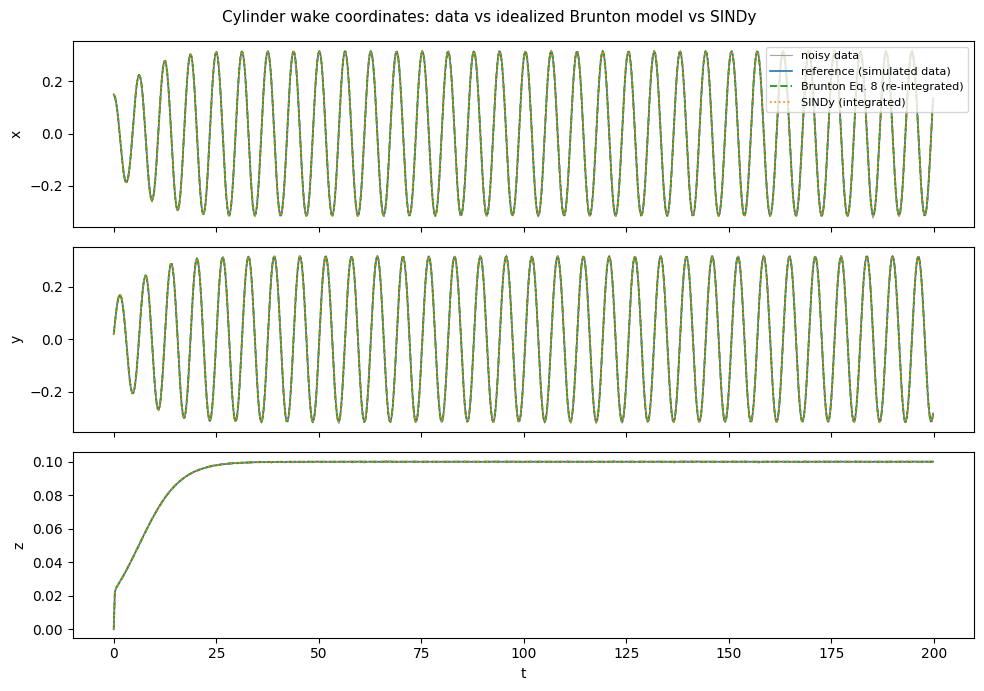

In [7]:
t_sub = t[::T_STRIDE]
Z_sub = Z_phys[::T_STRIDE]
Z_noisy_sub = Z_noisy[::T_STRIDE]

sol_br = simulate_cylinder_mean_field(
    (float(t_sub[0]), float(t_sub[-1])),
    z0,
    t_eval=t_sub,
    params=params,
)
Z_brunton = sol_br.y.T

from lorenz.integrated import integrate_discovered_sindy

Z_sindy_sub = integrate_discovered_sindy(res["fit"], z0, t_sub)

labels = ["x", "y", "z"]
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(t_sub, Z_noisy_sub[:, k], color="#7f7f7f", lw=0.8, alpha=0.7, label="noisy data")
    ax.plot(t_sub, Z_sub[:, k], color="#1f77b4", lw=1.2, label="reference (simulated data)")
    ax.plot(t_sub, Z_brunton[:, k], color="#2ca02c", lw=1.4, ls="--", label="Brunton Eq. 8 (re-integrated)")
    ax.plot(t_sub, Z_sindy_sub[:, k], color="#ff7f0e", lw=1.2, ls=":", label="SINDy (integrated)")
    ax.set_ylabel(labels[k])
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("t")
fig.suptitle("Cylinder wake coordinates: data vs idealized Brunton model vs SINDy", fontsize=11)
fig.tight_layout()
fig.savefig(output_dir + "cylinder_timeseries_data_vs_brunton_vs_sindy.png", dpi=160, bbox_inches="tight")
plt.show()
